<a href="https://colab.research.google.com/github/shravan1525/Employee-Attrition-Prediction/blob/main/Employee_Attrition_Analysis%26Prediction_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#getting the csv file
df=pd.read_csv("/content/employe.csv")

In [ ]:
df

,satisfactoryLevel,lastEvaluation,numberOfProjects,avgMonthlyHours,timeSpent.company,workAccident,left,promotionInLast5years,dept,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.37,0.52,2,159,3,0,1,0,sales,low
4,0.41,0.50,2,153,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14994,0.11,0.85,7,275,4,0,1,0,support,medium
14995,0.99,0.83,4,274,2,0,0,0,sales,low
14996,0.72,0.72,4,175,4,0,0,0,technical,low
14997,0.24,0.91,5,177,5,0,0,0,sales,low


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfactoryLevel      14999 non-null  float64
 1   lastEvaluation         14999 non-null  float64
 2   numberOfProjects       14999 non-null  int64  
 3   avgMonthlyHours        14999 non-null  int64  
 4   timeSpent.company      14999 non-null  int64  
 5   workAccident           14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotionInLast5years  14999 non-null  int64  
 8   dept                   14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [ ]:
df.shape

(14999, 10)

In [ ]:
df.isnull().sum()

,0
satisfactoryLevel,0
lastEvaluation,0
numberOfProjects,0
avgMonthlyHours,0
timeSpent.company,0
workAccident,0
left,0
promotionInLast5years,0
dept,0
salary,0


NO NULL VALUES

In [ ]:
df.duplicated().sum()

np.int64(3008)

3008 duplicate rows

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.shape

(11991, 10)

WE HAVE REMOVED THE DUPLICATED ROWS

In [ ]:
df

,satisfactoryLevel,lastEvaluation,numberOfProjects,avgMonthlyHours,timeSpent.company,workAccident,left,promotionInLast5years,dept,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.37,0.52,2,159,3,0,1,0,sales,low
4,0.41,0.50,2,153,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14992,0.30,0.88,5,245,4,0,0,0,hr,low
14995,0.99,0.83,4,274,2,0,0,0,sales,low
14996,0.72,0.72,4,175,4,0,0,0,technical,low
14997,0.24,0.91,5,177,5,0,0,0,sales,low


In [ ]:
df.head()

,satisfactoryLevel,lastEvaluation,numberOfProjects,avgMonthlyHours,timeSpent.company,workAccident,left,promotionInLast5years,dept,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.37,0.52,2,159,3,0,1,0,sales,low
4,0.41,0.50,2,153,3,0,1,0,sales,low


In [ ]:
df.columns

Index(['satisfactoryLevel', 'lastEvaluation', 'numberOfProjects',
       'avgMonthlyHours', 'timeSpent.company', 'workAccident', 'left',
       'promotionInLast5years', 'dept', 'salary'],
      dtype='object')

In [ ]:
df.describe()

,satisfactoryLevel,lastEvaluation,numberOfProjects,avgMonthlyHours,timeSpent.company,workAccident,left,promotionInLast5years
count,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000
mean,0.629658,0.716683,3.802852,200.473522,3.364857,0.154282,0.166041,0.016929
std,0.241070,0.168343,1.163238,48.727813,1.330240,0.361234,0.372133,0.129012
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.480000,0.570000,3.000000,157.000000,3.000000,0.000000,0.000000,0.000000
50%,0.660000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.860000,5.000000,243.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


In [ ]:
df['left'].value_counts()

,count
left,
0,10000
1,1991


target variable: left

*left = 0 → stayed

*left = 1 → resigned



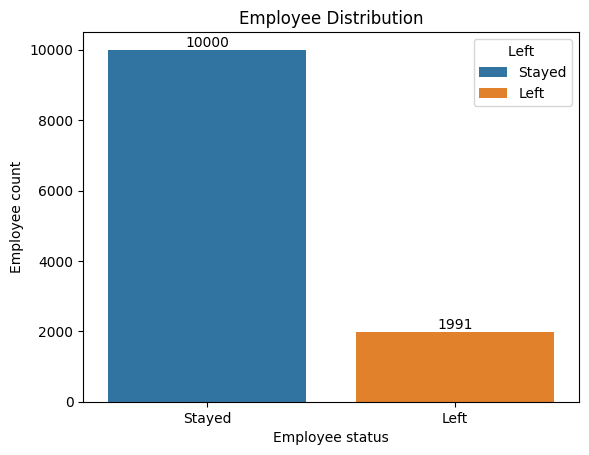

In [ ]:
x1=sns.countplot(x='left',data=df,hue='left')
x1.bar_label(x1.containers[0])
x1.bar_label(x1.containers[1])
plt.xlabel("Employee status")
plt.ylabel("Employee count")
plt.title("Employee Distribution")
plt.xticks([0,1], ["Stayed", "Left"])
plt.legend(title="Left ", labels=["Stayed", "Left"])
plt.show()

In [ ]:
'''
Number of projects vs attrition

Average monthly hours vs attrition

Salary vs attrition

work accident vs attrition

promotion last 5 years vs attrition

Satisfaction level vs attrition
'''

'\nNumber of projects vs attrition\n\nAverage monthly hours vs attrition\n\nSalary vs attrition\n\nwork accident vs attrition\n\npromotion last 5 years vs attrition\n\nSatisfaction level vs attrition\n'

In [ ]:
#Number of projects vs attrition
df[['numberOfProjects','left']]

,numberOfProjects,left
0,2,1
1,5,1
2,7,1
3,2,1
4,2,1
...,...,...
14992,5,0
14995,4,0
14996,4,0
14997,5,0


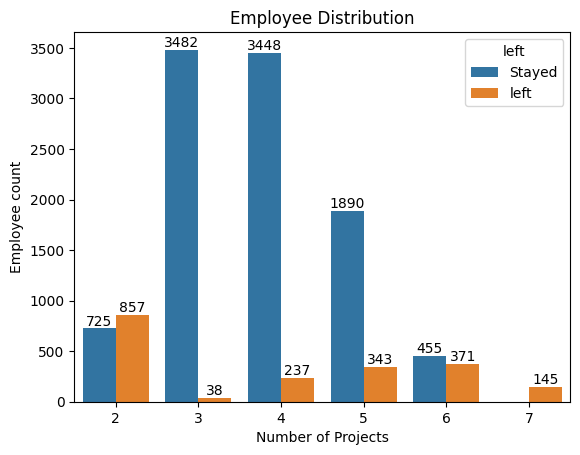

In [ ]:
x2=sns.countplot(x='numberOfProjects',data=df,hue='left')
x2.bar_label(x2.containers[0])
x2.bar_label(x2.containers[1])
plt.xlabel("Number of Projects")
plt.ylabel("Employee count")
plt.title("Employee Distribution")
plt.legend(title='left',labels=['Stayed','left'])
plt.show()



*Too few projects → employees leave

*Moderate projects → employees stay

*Too many projects → employees leave


---
The analysis of the number of projects shows a clear pattern in employee attrition. Employees handling a moderate number of projects (3–5) are more likely to stay with the company. However, employees with very few projects (2) and those with very high workloads (6–7) exhibit higher attrition rates. This suggests that both underutilization and excessive workload may contribute to employee turnover.
---





In [ ]:
#having modarate projects also the employes leves
a = df[(df['numberOfProjects'] >= 3) & (df['numberOfProjects'] <= 5)]
a['left'].value_counts()

,count
left,
0,8820
1,618


In [ ]:
###############################

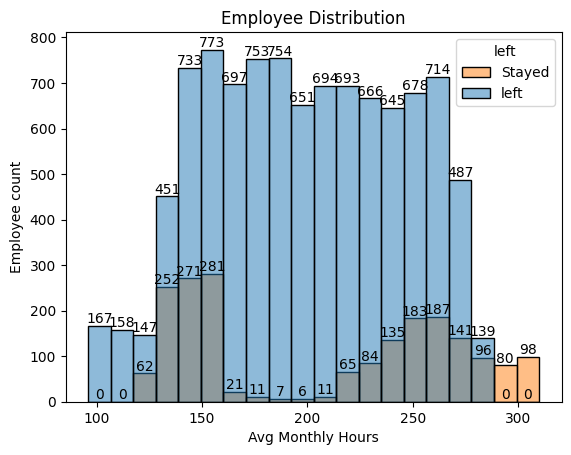

In [ ]:
x3=sns.histplot(x='avgMonthlyHours',data=df,hue='left',bins=20, alpha=0.5)
x3.bar_label(x3.containers[0])
x3.bar_label(x3.containers[1])
plt.xlabel("Avg Monthly Hours")
plt.ylabel("Employee count")
plt.title("Employee Distribution")
plt.legend(title='left',labels=['Stayed','left'])
plt.show()

In [ ]:
print(df["avgMonthlyHours"].mean())

200.4735218080227


In [ ]:
f1= df[(df['avgMonthlyHours'] < 200)]
f1['left'].value_counts()


,count
left,
0,5082
1,910


In [ ]:
f0= df[(df['avgMonthlyHours'] > 200)]
f0['left'].value_counts()

,count
left,
0,4865
1,1081


In [ ]:
filtered = df[(df['avgMonthlyHours'] < 200) & (df['numberOfProjects'] > 4)]
filtered['left'].value_counts()

,count
left,
0,1118
1,35


In [ ]:
f2 = df[(df['avgMonthlyHours'] < 200) & (df['workAccident'] ==1 )]
f2['left'].value_counts()

,count
left,
0,892
1,49


In [ ]:
f3 = df[(df['avgMonthlyHours'] < 200) & (df['promotionInLast5years'] ==0 )]
f3['left'].value_counts()

,count
left,
0,4987
1,904


In [ ]:
f4 = df[(df['avgMonthlyHours'] < 200) & ( (df['salary'] == 'low' ) | (df['salary'] == 'medium' ))]
f4['left'].value_counts()

,count
left,
0,4616
1,885


In [ ]:
f5=df[(df['avgMonthlyHours'] < 200) & (df['promotionInLast5years'] ==0 )  & (df['numberOfProjects'] > 4) & ( (df['salary'] == 'low' ) | (df['salary'] == 'medium' ))]
f5['left'].value_counts()

,count
left,
0,994
1,33


In [ ]:
################################################

In [ ]:
df[["salary","left"]].value_counts()

,,count
salary,left,
low,0,4566
medium,0,4492
low,1,1174
high,0,942
medium,1,769
high,1,48


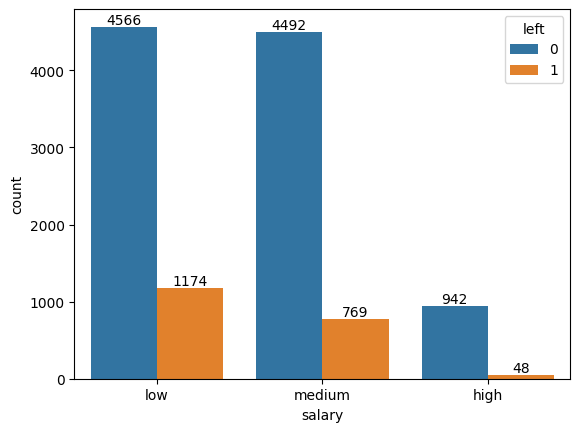

In [ ]:
x4 = sns.countplot(x='salary', data=df, hue='left')
x4.bar_label(x4.containers[0])
x4.bar_label(x4.containers[1])
plt.show()

if salary is high there is less chance of employee attrition


if salary is low there is high chance of employee attrition

In [ ]:
c=df[(df['salary']=='high')&(df['left']==1)]
c.count().sum()

np.int64(480)

In [ ]:
f5 = df[(df['salary'] =='high') & (df['promotionInLast5years'] ==0 )]
f5['left'].value_counts()

,count
left,
0,898
1,48


In [ ]:
f6 = df[(df['salary'] =='high') & (df['avgMonthlyHours'] >200)]
f6['left'].value_counts()

,count
left,
0,475
1,23


In [ ]:
f7 = df[(df['salary'] =='high') & (df['numberOfProjects'] >4)]
f7['left'].value_counts()

,count
left,
0,236
1,22


In [ ]:
f8 = df[(df['salary'] =='high') & (df['workAccident']==1)]
f8['left'].value_counts()

,count
left,
0,156


In [ ]:
#####################

In [ ]:
df[["workAccident","left"]].value_counts()

workAccident  left
0             0       8255
              1       1886
1             0       1745
              1        105
Name: count, dtype: int64

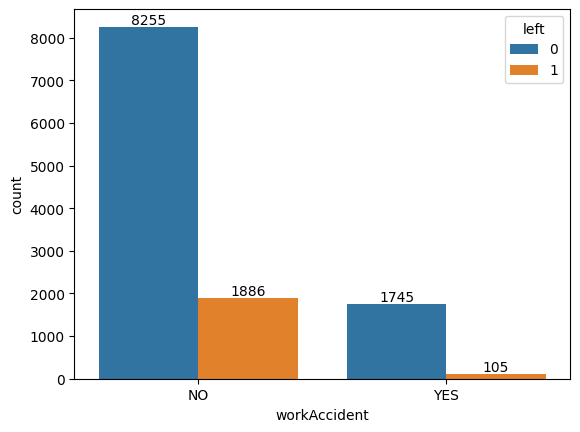

In [ ]:
x5 = sns.countplot(x='workAccident', data=df, hue='left')
x5.bar_label(x5.containers[0])
x5.bar_label(x5.containers[1])
plt.xticks([0,1],["NO","YES"])
plt.show()

Work_accident = 0 → having low chance of employee attrition




Work_accident = 1 → having high chance of employee attrition

In [ ]:
#################################

In [ ]:
df[["promotionInLast5years","left"]].value_counts()

promotionInLast5years  left
0                      0       9805
                       1       1983
1                      0        195
                       1          8
Name: count, dtype: int64

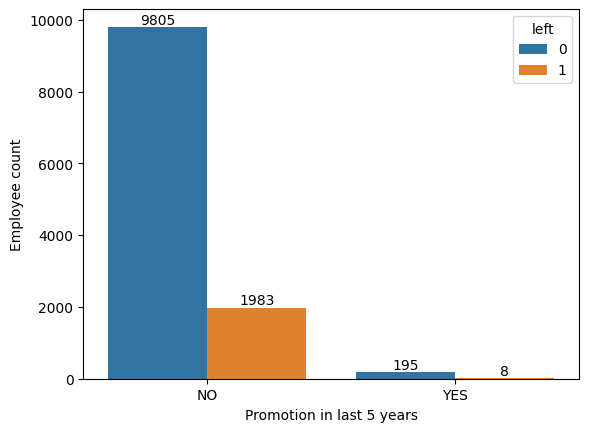

In [ ]:
x6 = sns.countplot(x='promotionInLast5years', data=df, hue='left')
x6.bar_label(x6.containers[0])
x6.bar_label(x6.containers[1])
plt.xlabel("Promotion in last 5 years")
plt.ylabel("Employee count")
plt.xticks([0,1],["NO","YES"])
plt.show()

Promotion in last 5 years = 1 → having low chance of employee attrition

Promotion in last 5 years = 0 → having high chance of employee attrition

In [ ]:
f9 = df[(df['promotionInLast5years'] == 1) & ((df['salary']=='low')|(df['salary']=='medium'))]
f9['left'].value_counts()

,count
left,
0,151
1,8


In [ ]:
####################

In [ ]:
df[['dept',"left"]].value_counts().sort_index()

dept         left
IT           0        818
             1        158
RandD        0        609
             1         85
accounting   0        512
             1        109
hr           0        488
             1        113
management   0        384
             1         52
marketing    0        561
             1        112
product_mng  0        576
             1        110
sales        0       2689
             1        550
support      0       1509
             1        312
technical    0       1854
             1        390
Name: count, dtype: int64

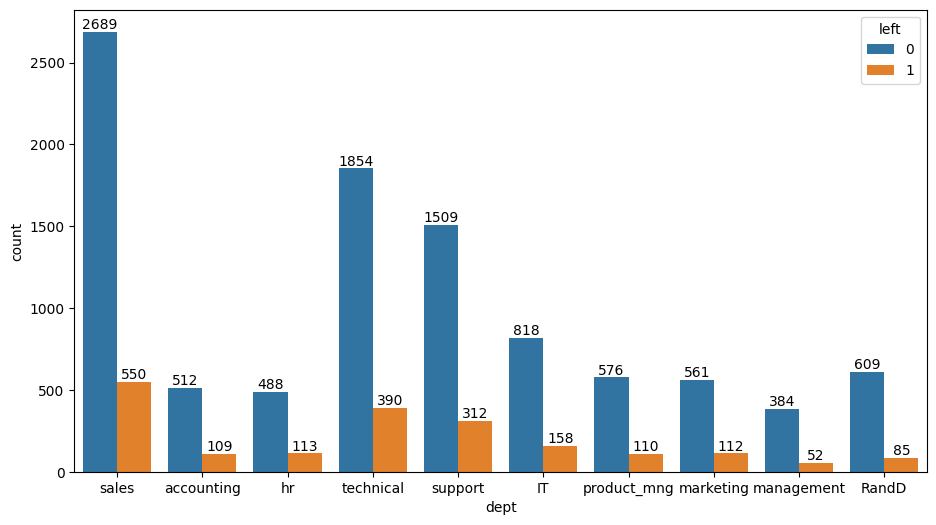

In [ ]:
plt.figure(figsize=(11,6))
x7 = sns.countplot(x='dept', data=df, hue='left')
x7.bar_label(x7.containers[0])
x7.bar_label(x7.containers[1])
plt.show()

In [ ]:
df[['satisfactoryLevel','left']].value_counts()

,,count
satisfactoryLevel,left,
0.10,1,203
0.50,0,198
0.11,1,188
0.66,0,186
0.74,0,186
...,...,...
0.33,1,1
0.67,1,1
0.65,1,1


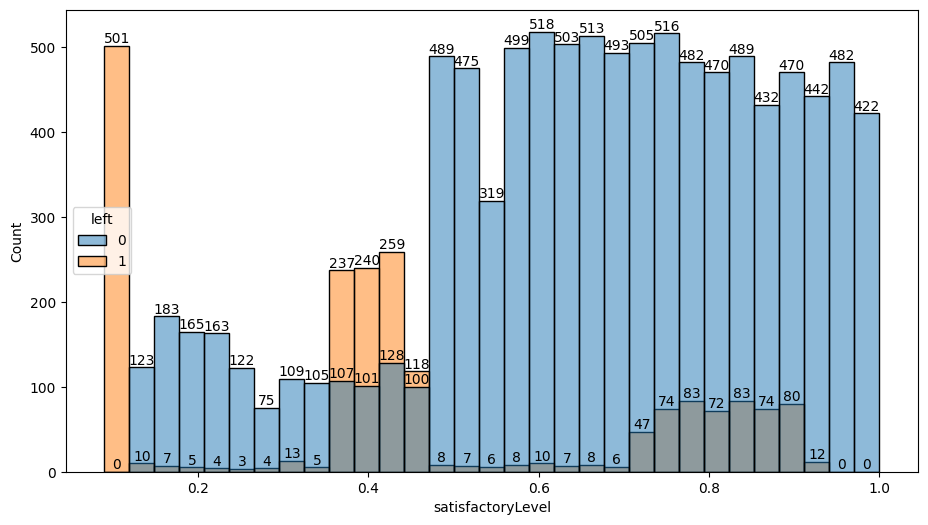

In [ ]:
plt.figure(figsize=(11,6))
x8 = sns.histplot(x='satisfactoryLevel', data=df, hue='left')
x8.bar_label(x8.containers[0])
x8.bar_label(x8.containers[1])
plt.show()

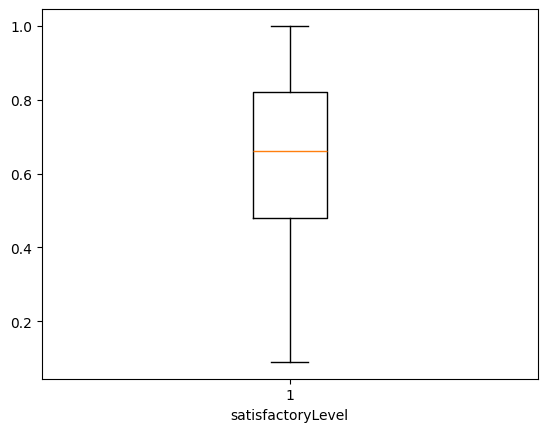

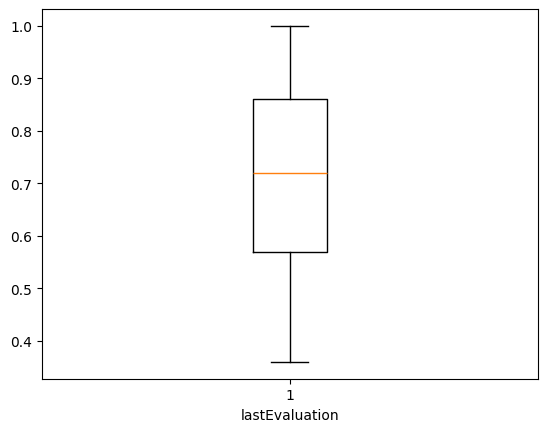

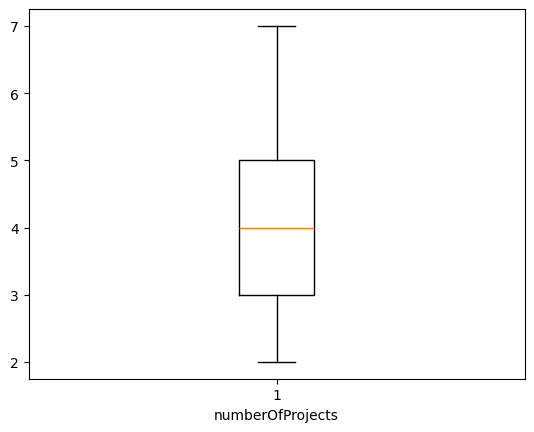

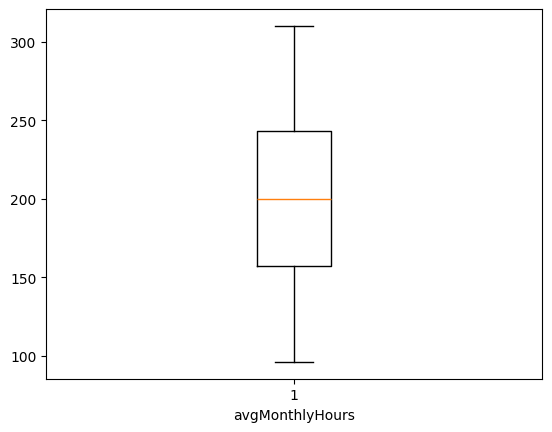

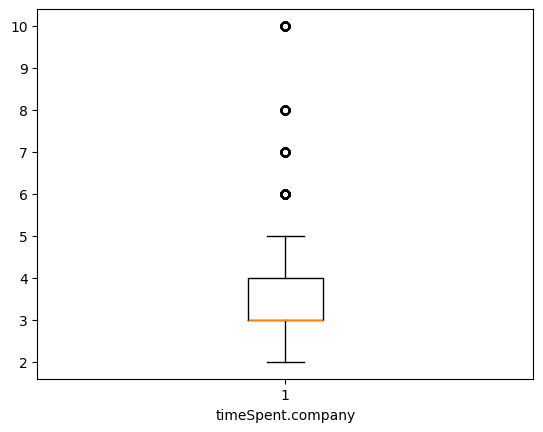

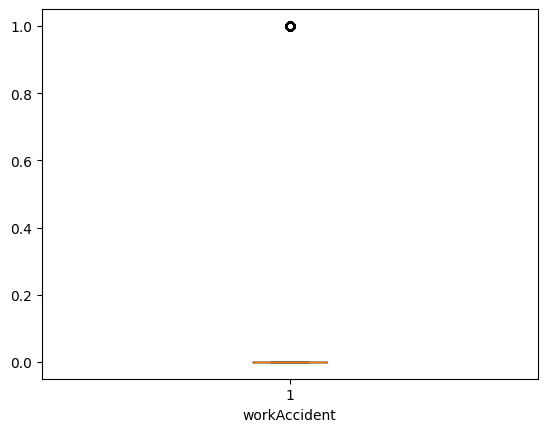

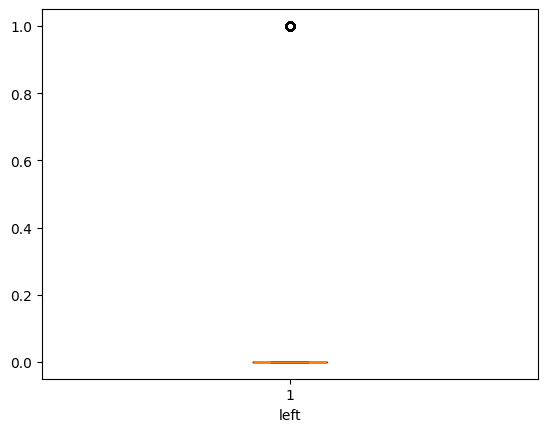

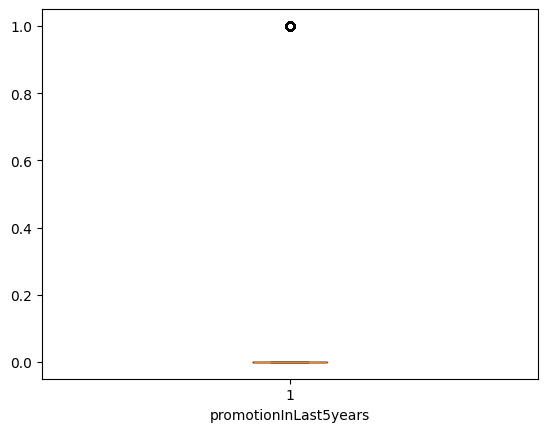

In [ ]:
for i in df.columns:
  if df[i].dtypes!='object':
    plt.boxplot(df[i])
    plt.xlabel(i)
    plt.show()

In [ ]:
data1 =df

In [ ]:
data1

,satisfactoryLevel,lastEvaluation,numberOfProjects,avgMonthlyHours,timeSpent.company,workAccident,left,promotionInLast5years,dept,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.37,0.52,2,159,3,0,1,0,sales,low
4,0.41,0.50,2,153,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14992,0.30,0.88,5,245,4,0,0,0,hr,low
14995,0.99,0.83,4,274,2,0,0,0,sales,low
14996,0.72,0.72,4,175,4,0,0,0,technical,low
14997,0.24,0.91,5,177,5,0,0,0,sales,low


In [ ]:
from sklearn.preprocessing import LabelEncoder
for i in data1.columns:
  if data1[i].dtype =='object':
    le=LabelEncoder()
    data1[i] = le.fit_transform(data1[i])

In [ ]:
data1

,satisfactoryLevel,lastEvaluation,numberOfProjects,avgMonthlyHours,timeSpent.company,workAccident,left,promotionInLast5years,dept,salary
0,0.38,0.53,2,157,3,0,1,0,7,1
1,0.80,0.86,5,262,6,0,1,0,7,2
2,0.11,0.88,7,272,4,0,1,0,7,2
3,0.37,0.52,2,159,3,0,1,0,7,1
4,0.41,0.50,2,153,3,0,1,0,7,1
...,...,...,...,...,...,...,...,...,...,...
14992,0.30,0.88,5,245,4,0,0,0,3,1
14995,0.99,0.83,4,274,2,0,0,0,7,1
14996,0.72,0.72,4,175,4,0,0,0,9,1
14997,0.24,0.91,5,177,5,0,0,0,7,1


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
col_list = []
for i in data1.columns:
  if((data1[i].dtype!='object') & (i!='left')):
    col_list.append(i)


X = data1[col_list]
vif_data = pd.DataFrame()
vif_data['Column_name'] = X.columns
vif_data['VIF_Score'] = [variance_inflation_factor(X.values,i) for i in range(len(X.columns))]
vif_data

,Column_name,VIF_Score
0,satisfactoryLevel,7.004667
1,lastEvaluation,19.312441
2,numberOfProjects,13.688030
3,avgMonthlyHours,18.392629
4,timeSpent.company,7.192605
5,workAccident,1.182573
6,promotionInLast5years,1.023093
7,dept,4.701758
8,salary,5.168760


In [ ]:
data1 = data1.drop(['lastEvaluation'],axis=1)

In [ ]:
data1

,satisfactoryLevel,numberOfProjects,avgMonthlyHours,timeSpent.company,workAccident,left,promotionInLast5years,dept,salary
0,0.38,2,157,3,0,1,0,7,1
1,0.80,5,262,6,0,1,0,7,2
2,0.11,7,272,4,0,1,0,7,2
3,0.37,2,159,3,0,1,0,7,1
4,0.41,2,153,3,0,1,0,7,1
...,...,...,...,...,...,...,...,...,...
14992,0.30,5,245,4,0,0,0,3,1
14995,0.99,4,274,2,0,0,0,7,1
14996,0.72,4,175,4,0,0,0,9,1
14997,0.24,5,177,5,0,0,0,7,1


In [ ]:
col_list = []
for i in data1.columns:
  if((data1[i].dtype!='object') & (i!='left')):
    col_list.append(i)


X = data1[col_list]
vif_data = pd.DataFrame()
vif_data['Column_name'] = X.columns
vif_data['VIF_Score'] = [variance_inflation_factor(X.values,i) for i in range(len(X.columns))]
vif_data

,Column_name,VIF_Score
0,satisfactoryLevel,6.291235
1,numberOfProjects,12.425857
2,avgMonthlyHours,16.163464
3,timeSpent.company,6.957435
4,workAccident,1.182436
5,promotionInLast5years,1.022921
6,dept,4.645233
7,salary,5.095531


data1 = data1.drop(['avgMonthlyHours'],axis=1)

In [ ]:
data1

,satisfactoryLevel,numberOfProjects,avgMonthlyHours,timeSpent.company,workAccident,left,promotionInLast5years,dept,salary
0,0.38,2,157,3,0,1,0,7,1
1,0.80,5,262,6,0,1,0,7,2
2,0.11,7,272,4,0,1,0,7,2
3,0.37,2,159,3,0,1,0,7,1
4,0.41,2,153,3,0,1,0,7,1
...,...,...,...,...,...,...,...,...,...
14992,0.30,5,245,4,0,0,0,3,1
14995,0.99,4,274,2,0,0,0,7,1
14996,0.72,4,175,4,0,0,0,9,1
14997,0.24,5,177,5,0,0,0,7,1


In [ ]:
col_list = []
for i in data1.columns:
  if((data1[i].dtype!='object') & (i!='left')):
    col_list.append(i)


X = data1[col_list]
vif_data = pd.DataFrame()
vif_data['Column_name'] = X.columns
vif_data['VIF_Score'] = [variance_inflation_factor(X.values,i) for i in range(len(X.columns))]
vif_data

,Column_name,VIF_Score
0,satisfactoryLevel,6.291235
1,numberOfProjects,12.425857
2,avgMonthlyHours,16.163464
3,timeSpent.company,6.957435
4,workAccident,1.182436
5,promotionInLast5years,1.022921
6,dept,4.645233
7,salary,5.095531


In [ ]:
data1

,satisfactoryLevel,numberOfProjects,avgMonthlyHours,timeSpent.company,workAccident,left,promotionInLast5years,dept,salary
0,0.38,2,157,3,0,1,0,7,1
1,0.80,5,262,6,0,1,0,7,2
2,0.11,7,272,4,0,1,0,7,2
3,0.37,2,159,3,0,1,0,7,1
4,0.41,2,153,3,0,1,0,7,1
...,...,...,...,...,...,...,...,...,...
14992,0.30,5,245,4,0,0,0,3,1
14995,0.99,4,274,2,0,0,0,7,1
14996,0.72,4,175,4,0,0,0,9,1
14997,0.24,5,177,5,0,0,0,7,1


In [ ]:
x=data1.drop(['left'],axis=1)
x

,satisfactoryLevel,numberOfProjects,avgMonthlyHours,timeSpent.company,workAccident,promotionInLast5years,dept,salary
0,0.38,2,157,3,0,0,7,1
1,0.80,5,262,6,0,0,7,2
2,0.11,7,272,4,0,0,7,2
3,0.37,2,159,3,0,0,7,1
4,0.41,2,153,3,0,0,7,1
...,...,...,...,...,...,...,...,...
14992,0.30,5,245,4,0,0,3,1
14995,0.99,4,274,2,0,0,7,1
14996,0.72,4,175,4,0,0,9,1
14997,0.24,5,177,5,0,0,7,1


In [ ]:
y=data1['left']
y

,left
0,1
1,1
2,1
3,1
4,1
...,...
14992,0
14995,0
14996,0
14997,0


In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.2,random_state=7)

In [ ]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()

In [ ]:
model.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
y_predit=model.predict(x_test)

In [ ]:
y_predit

array([0, 0, 0, ..., 0, 0, 0])

In [ ]:
from sklearn.metrics import accuracy_score,confusion_matrix

In [ ]:
accuracy_score(y_test,y_predit)

0.8328470195914964

In [ ]:
def employee_status_preditor(a):
  df1 = pd.DataFrame([a], columns=['satisfactoryLevel', 'numberOfProjects', 'avgMonthlyHours', 'timeSpent.company', 'workAccident', 'promotionInLast5years', 'dept', 'salary'])
  a=model.predict(df1)
  return a
a=[0.8,5,200,6,0,1,7,2] # Added 'avgMonthlyHours' value (200) at the appropriate position
employee_status_preditor(a)

array([0])